# Import Libraries


In [1]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader, SequentialSampler, WeightedRandomSampler
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import random
import os
from tqdm.auto import tqdm
from tqdm import tqdm
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertTokenizer, BertForSequenceClassification, AutoTokenizer, RobertaForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
import torch.nn as nn
import datetime
import shap
from collections import Counter
from sklearn.preprocessing import LabelEncoder

2025-06-07 03:54:52.240736: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749268492.431709      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749268492.492521      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


#  Reproducibility

In [2]:
# SET RANDOM SEEDS FOR REPRODUCIBILITY
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the dataset


In [3]:
# Load Data
file_path = '/kaggle/input/personal-care/amazon_reviews_us_Personal_Care_Appliances_v1_00.tsv'
df = pd.read_csv(file_path, on_bad_lines='skip', sep='\t')

# Display the shape of the dataset


In [4]:
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.\n")

Dataset contains 85924 rows and 15 columns.



# Display the first few rows


In [5]:
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date
0,US,32114233,R1QX6706ZWJ1P5,B00OYRW4UE,223980852,Elite Sportz Exercise Sliders are Double Sided...,Personal_Care_Appliances,5,0,0,N,Y,Good quality. Shipped,Exactly as described. Good quality. Shipped fast,2015-08-31
1,US,18125776,R3QWMLJHIW6P37,B0000537JQ,819771537,Ezy Dose Weekly,Personal_Care_Appliances,5,0,0,N,Y,Five Stars,It is great,2015-08-31
2,US,19917519,R14Z1VR1N0Z9G6,B00HXXO332,849307176,"Pulse Oximeter, Blood Oxygen Monitor",Personal_Care_Appliances,5,1,1,N,Y,It's really nice it works great,It's really nice it works great. You have the ...,2015-08-31
3,US,18277171,R25ZRJL0GH0U0,B00EOB0JA2,700864740,SE Tools Tool Kit Watch Watch Repair Kit (20 P...,Personal_Care_Appliances,2,0,0,N,Y,Two Stars,The kit works fine... simple cheap plastic tho,2015-08-31
4,US,2593270,R3837KYH7AZNIY,B00OC2O1UC,794298839,"doTERRA HD Clear Facial Kit - Facial Lotion, F...",Personal_Care_Appliances,4,0,1,N,Y,Four Stars,It works better than anything else ive tried,2015-08-31


# Display column names


In [6]:
print("\nColumn names:")
df.columns.tolist()


Column names:


['marketplace',
 'customer_id',
 'review_id',
 'product_id',
 'product_parent',
 'product_title',
 'product_category',
 'star_rating',
 'helpful_votes',
 'total_votes',
 'vine',
 'verified_purchase',
 'review_headline',
 'review_body',
 'review_date']

# Display data types and non-null counts


In [7]:
print("\nDataset info:")
df.info()


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85924 entries, 0 to 85923
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   marketplace        85924 non-null  object
 1   customer_id        85924 non-null  int64 
 2   review_id          85924 non-null  object
 3   product_id         85924 non-null  object
 4   product_parent     85924 non-null  int64 
 5   product_title      85920 non-null  object
 6   product_category   85924 non-null  object
 7   star_rating        85924 non-null  int64 
 8   helpful_votes      85924 non-null  int64 
 9   total_votes        85924 non-null  int64 
 10  vine               85924 non-null  object
 11  verified_purchase  85924 non-null  object
 12  review_headline    85923 non-null  object
 13  review_body        85924 non-null  object
 14  review_date        85924 non-null  object
dtypes: int64(5), object(10)
memory usage: 9.8+ MB


# Display summary statistics for numerical columns


In [8]:
print("\nSummary statistics:")
df.describe()


Summary statistics:


,customer_id,product_parent,star_rating,helpful_votes,total_votes
count,8.592400e+04,8.592400e+04,85924.000000,85924.000000,85924.000000
mean,2.943395e+07,5.138159e+08,3.977236,3.351520,4.061357
std,1.525241e+07,2.919951e+08,1.433323,19.489455,20.832674
min,1.047000e+04,3.573000e+03,1.000000,0.000000,0.000000
25%,1.547730e+07,2.628535e+08,3.000000,0.000000,0.000000
50%,2.903199e+07,4.981086e+08,5.000000,0.000000,1.000000
75%,4.372740e+07,7.899794e+08,5.000000,2.000000,3.000000
max,5.309657e+07,9.999599e+08,5.000000,2785.000000,2876.000000


# Check for missing values


In [9]:
print("\nMissing values per column:")
df.isnull().sum()


Missing values per column:


marketplace          0
customer_id          0
review_id            0
product_id           0
product_parent       0
product_title        4
product_category     0
star_rating          0
helpful_votes        0
total_votes          0
vine                 0
verified_purchase    0
review_headline      1
review_body          0
review_date          0
dtype: int64

# Check rating distribution


 Rating Distribution:


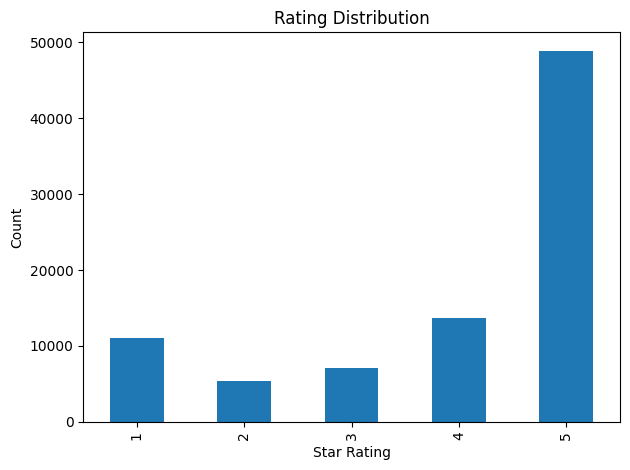

<Figure size 640x480 with 0 Axes>

In [10]:
if 'star_rating' in df.columns:
    print("\n Rating Distribution:")
    df['star_rating'].value_counts().sort_index()

    df['star_rating'].value_counts().sort_index().plot(kind='bar', title='Rating Distribution')
    plt.xlabel('Star Rating')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()  
    plt.clf()

# Calculate and plot string length (characters)

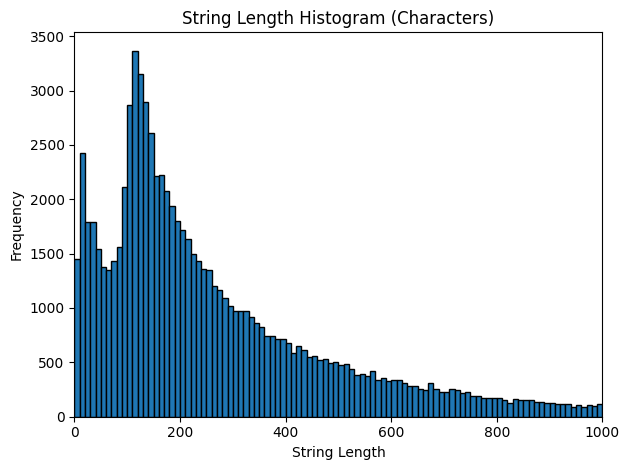

<Figure size 640x480 with 0 Axes>

In [11]:
df['String_Length'] = df['review_body'].astype(str).apply(len)

plt.hist(df['String_Length'], 
         bins=range(0, 1001, 10),  # bin every 10 chars up to 1000
         edgecolor='black')
plt.title('String Length Histogram (Characters)')
plt.xlabel('String Length')
plt.ylabel('Frequency')
plt.xlim(0, 1000)
plt.tight_layout()
plt.show()
plt.clf()

# Calculate and plot word count

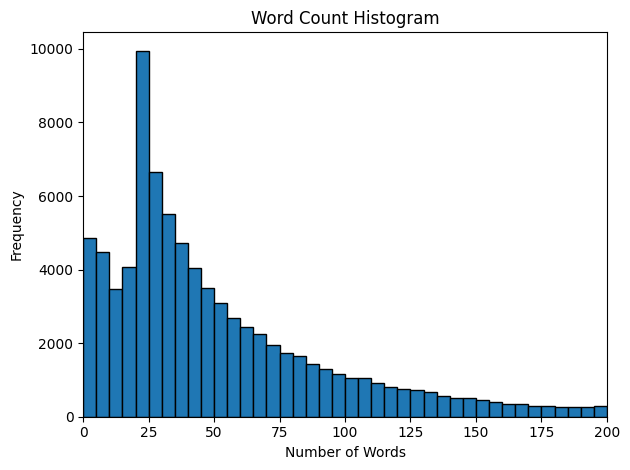

<Figure size 640x480 with 0 Axes>

In [12]:
df['Word_Count'] = df['review_body'].astype(str).apply(lambda x: len(x.split()))

plt.hist(df['Word_Count'], 
         bins=range(0, 201, 5),  # bin every 5 words up to 200
         edgecolor='black')
plt.title('Word Count Histogram')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.xlim(0, 200)
plt.tight_layout()
plt.show()
plt.clf()

# 1. Data Preprocessing


# Drop rows with missing values


In [13]:
df = df[['star_rating', 'product_title', 'review_headline', 'review_body']].dropna()

# Convert star ratings to sentiment classes (0: Negative, 1: Neutral, 2: Positive)


In [14]:
df['star_rating'] = pd.to_numeric(df['star_rating'], errors='coerce')
df['sentiment'] = df['star_rating'].apply(lambda x: 0 if x <= 3 else 1)

# Combine 3 columns

In [15]:
df['combined_text'] = df['product_title'] + " " + df['review_headline'] + " " + df['review_body']
df['combined_text'] = df['combined_text'].apply(lambda x: ' '.join(x.split()[:128]))
labels = torch.tensor(df['sentiment'].values)

# Print class distribution


In [16]:
# Label mapping for binary classification
label_names = {0: "Negative", 1: "Positive"}

# Count occurrences
class_counts = np.bincount(df['sentiment'])
total_samples = len(df)

print("Class Distribution (Full Dataset):")
for label, count in enumerate(class_counts):
    percentage = count / total_samples * 100
    print(f"{label_names[label]}: {count} samples ({percentage:.2f}%)")


Class Distribution (Full Dataset):
Negative: 23415 samples (27.25%)
Positive: 62504 samples (72.75%)


# View cleaned data

In [17]:
print("\nPreview of Cleaned Data:")
df[['star_rating', 'sentiment', 'combined_text']].sample(10, random_state=42)


Preview of Cleaned Data:


,star_rating,sentiment,combined_text
226,5,1,Viva Naturals #1 Best Selling Certified Organi...
71481,3,0,Clean + Easy Deluxe Home Electrolysis If you h...
72642,5,1,The Acuvibe Wireless Massager Amazing! I first...
11687,1,0,Personal Pedi Water Proof Electronic Hand and ...
71552,5,1,Denman Denman Styling Brush Heavy Weight 9 Row...
37974,5,1,Vktech Replacement Electric Toothbrush Heads P...
58155,4,1,"Lock Laces, Black Good For Those With Little T..."
39741,5,1,Oral-B Power Tip Replacement Electric Toothbru...
28511,2,0,Mega Motion Infinate Position Power Easy Comfo...
48480,5,1,"IQAir Pre-Filter Replacement for HealthPro, He..."


# 2. Tokenize function


In [18]:
# Tokenization
MAX_LEN = 96
BATCH_SIZE = 16
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
roberta_tokenizer = AutoTokenizer.from_pretrained('roberta-base')

def tokenize_dataset(texts, tokenizer):
    input_ids, attention_masks = [], []
    for text in tqdm(texts):
        encoded = tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt')
        input_ids.append(encoded['input_ids'].squeeze(0))
        attention_masks.append(encoded['attention_mask'].squeeze(0))
    return torch.stack(input_ids), torch.stack(attention_masks)

bert_ids, bert_masks = tokenize_dataset(df['combined_text'], bert_tokenizer)
roberta_ids, roberta_masks = tokenize_dataset(df['combined_text'], roberta_tokenizer)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

100%|██████████| 85919/85919 [00:36<00:00, 2330.75it/s]


# 3. Dataset splits (60% train, 25% val, 15% test)

In [19]:
# Zipped input-mask pairs for splitting
X_b = list(zip(bert_ids, bert_masks))
X_r = list(zip(roberta_ids, roberta_masks))

# Step 1: Hold out 15% for final test
X_temp_b, X_test_b, X_temp_r, X_test_r, y_temp, y_test = train_test_split(
    X_b, X_r, labels, test_size=0.15, stratify=labels, random_state=SEED)

# Step 2: From remaining 85%, take ≈29.41% (which equals 25% of full) for validation
X_train_b, X_val_b, X_train_r, X_val_r, y_train, y_val = train_test_split(
    X_temp_b, X_temp_r, y_temp, test_size=0.2941, stratify=y_temp, random_state=SEED)

# Unpack tensors
X_train_b, train_masks_b = zip(*X_train_b)
X_val_b, val_masks_b = zip(*X_val_b)
X_test_b, test_masks_b = zip(*X_test_b)
X_train_r, train_masks_r = zip(*X_train_r)
X_val_r, val_masks_r = zip(*X_val_r)
X_test_r, test_masks_r = zip(*X_test_r)

# Stack
X_train_b = torch.stack(X_train_b)
val_masks_b = torch.stack(val_masks_b)
X_val_b = torch.stack(X_val_b)
train_masks_b = torch.stack(train_masks_b)
X_test_b = torch.stack(X_test_b)
test_masks_b = torch.stack(test_masks_b)
X_train_r = torch.stack(X_train_r)
train_masks_r = torch.stack(train_masks_r)
X_val_r = torch.stack(X_val_r)
val_masks_r = torch.stack(val_masks_r)
X_test_r = torch.stack(X_test_r)
test_masks_r = torch.stack(test_masks_r)

# 4. Compute class weights


In [20]:
# Class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train.numpy()), y=y_train.numpy())
weights_train = torch.tensor([class_weights[label] for label in y_train.numpy()], dtype=torch.float)
train_sampler = WeightedRandomSampler(weights_train, num_samples=len(weights_train), replacement=True)
train_sampler_r = WeightedRandomSampler(weights_train, num_samples=len(weights_train), replacement=True)

# Data Loaders

In [21]:
# === Loaders Already Defined ===
print(f"Total Samples: Train={len(y_train)}, Val={len(y_val)}, Test={len(y_test)}")

train_loader_b = DataLoader(TensorDataset(X_train_b, train_masks_b, y_train), sampler=train_sampler, batch_size=BATCH_SIZE)
val_loader_b = DataLoader(TensorDataset(X_val_b, val_masks_b, y_val), sampler=SequentialSampler(X_val_b), batch_size=BATCH_SIZE)
test_loader_b = DataLoader(TensorDataset(X_test_b, test_masks_b, y_test), sampler=SequentialSampler(X_test_b), batch_size=BATCH_SIZE)

train_loader_r = DataLoader(TensorDataset(X_train_r, train_masks_r, y_train), sampler=train_sampler_r, batch_size=BATCH_SIZE)
val_loader_r = DataLoader(TensorDataset(X_val_r, val_masks_r, y_val), sampler=SequentialSampler(X_val_r), batch_size=BATCH_SIZE)
test_loader_r = DataLoader(TensorDataset(X_test_r, test_masks_r, y_test), sampler=SequentialSampler(X_test_r), batch_size=BATCH_SIZE)


Total Samples: Train=51552, Val=21479, Test=12888


# 5. DEFINE MODELS + TRAINING FUNCTION


In [22]:
EPOCHS = 3

# === Model Training Function ===
def train_model(model, train_loader, val_loader, model_path='model.pt', name='Model'):
    optimizer = AdamW(model.parameters(), lr=5e-6, eps=1e-8, weight_decay=0.1)
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, int(0.1 * total_steps), total_steps)
    best_val_loss = float('inf')
    model.to(device)

    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(EPOCHS):
        model.train()
        train_loss, train_correct, total_train = 0, 0, 0
        for batch in tqdm(train_loader, desc=f"[{name}] Epoch {epoch+1}/{EPOCHS}"):
            input_ids, masks, labels = [x.to(device) for x in batch]
            model.zero_grad()
            outputs = model(input_ids, attention_mask=masks, labels=labels)
            loss = outputs.loss
            logits = outputs.logits
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            train_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            train_correct += (preds == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = train_loss / len(train_loader)
        avg_train_acc = train_correct / total_train

        # Validation
        model.eval()
        val_loss, val_correct, total_val = 0, 0, 0
        for batch in val_loader:
            input_ids, masks, labels = [x.to(device) for x in batch]
            with torch.no_grad():
                outputs = model(input_ids, attention_mask=masks, labels=labels)
            loss = outputs.loss
            logits = outputs.logits
            val_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == labels).sum().item()
            total_val += labels.size(0)

        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc = val_correct / total_val

        # Save logs
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(avg_train_acc)
        val_accs.append(avg_val_acc)

        print(f"[{name}] Epoch {epoch+1}/{EPOCHS} | "
              f"Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_acc:.4f} | "
              f"Val Loss: {avg_val_loss:.4f}, Val Acc: {avg_val_acc:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), model_path)

    return model_path, train_losses, val_losses, train_accs, val_accs

# === Train BERT and RoBERTa ===
bert_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
bert_path, b_loss, b_val_loss, b_acc, b_val_acc = train_model(bert_model, train_loader_b, val_loader_b, model_path='bert_best.pt', name='BERT')
del bert_model; gc.collect(); torch.cuda.empty_cache()

roberta_model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)
roberta_path, r_loss, r_val_loss, r_acc, r_val_acc = train_model(roberta_model, train_loader_r, val_loader_r, model_path='roberta_best.pt', name='RoBERTa')
del roberta_model; gc.collect(); torch.cuda.empty_cache()


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[BERT] Epoch 1/3: 100%|██████████| 3222/3222 [16:00<00:00,  3.35it/s]


[BERT] Epoch 1/3 | Train Loss: 0.2894, Train Acc: 0.8777 | Val Loss: 0.2224, Val Acc: 0.9248


[BERT] Epoch 2/3: 100%|██████████| 3222/3222 [16:07<00:00,  3.33it/s]


[BERT] Epoch 2/3 | Train Loss: 0.1691, Train Acc: 0.9452 | Val Loss: 0.2205, Val Acc: 0.9352


...

[RoBERTa] Epoch 1/3 | Train Loss: 0.2784, Train Acc: 0.8788 | Val Loss: 0.2008, Val Acc: 0.9431


[RoBERTa] Epoch 2/3: 100%|██████████| 3222/3222 [16:24<00:00,  3.27it/s]


[RoBERTa] Epoch 2/3 | Train Loss: 0.1675, Train Acc: 0.9513 | Val Loss: 0.2461, Val Acc: 0.9416


[RoBERTa] Epoch 3/3: 100%|██████████| 3222/3222 [16:22<00:00,  3.28it/s]


[RoBERTa] Epoch 3/3 | Train Loss: 0.1489, Train Acc: 0.9600 | Val Loss: 0.2418, Val Acc: 0.9408


In [23]:
# === Reload Best Models ===
bert_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
bert_model.load_state_dict(torch.load('bert_best.pt'))
bert_model.to(device).eval()

roberta_model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)
roberta_model.load_state_dict(torch.load('roberta_best.pt'))
roberta_model.to(device).eval()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

# 6. ENSEMBLE INFERENCE

In [24]:
# === Soft Voting Ensemble ===
def ensemble_predict_weighted(bert_model, roberta_model, test_loader_b, test_loader_r, bert_weight=0.4, roberta_weight=0.6):
    bert_model.eval()
    roberta_model.eval()
    all_preds, all_labels = [], []
    for b_batch, r_batch in zip(test_loader_b, test_loader_r):
        b_ids, b_masks, b_labels = [x.to(device) for x in b_batch]
        r_ids, r_masks, _ = [x.to(device) for x in r_batch]
        with torch.no_grad():
            b_probs = torch.softmax(bert_model(b_ids, attention_mask=b_masks).logits, dim=1)
            r_probs = torch.softmax(roberta_model(r_ids, attention_mask=r_masks).logits, dim=1)
            avg_probs = bert_weight * b_probs + roberta_weight * r_probs
            preds = torch.argmax(avg_probs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(b_labels.cpu().numpy())
    return all_labels, all_preds

true_labels, ensemble_preds = ensemble_predict_weighted(
    bert_model, roberta_model, test_loader_b, test_loader_r, bert_weight=0.4, roberta_weight=0.6
)

print("\n🔁 Soft Voting Ensemble Evaluation")
print(f"Accuracy : {accuracy_score(true_labels, ensemble_preds):.4f}")
print(classification_report(true_labels, ensemble_preds, target_names=['Negative', 'Positive']))


🔁 Soft Voting Ensemble Evaluation
Accuracy : 0.9465
              precision    recall  f1-score   support

    Negative       0.89      0.91      0.90      3512
    Positive       0.97      0.96      0.96      9376

    accuracy                           0.95     12888
   macro avg       0.93      0.94      0.93     12888
weighted avg       0.95      0.95      0.95     12888



# 7. Evaluation



🔁 Meta-Classifier Ensemble Evaluation
Accuracy : 0.9470
              precision    recall  f1-score   support

    Negative       0.91      0.90      0.90      3512
    Positive       0.96      0.97      0.96      9376

    accuracy                           0.95     12888
   macro avg       0.93      0.93      0.93     12888
weighted avg       0.95      0.95      0.95     12888



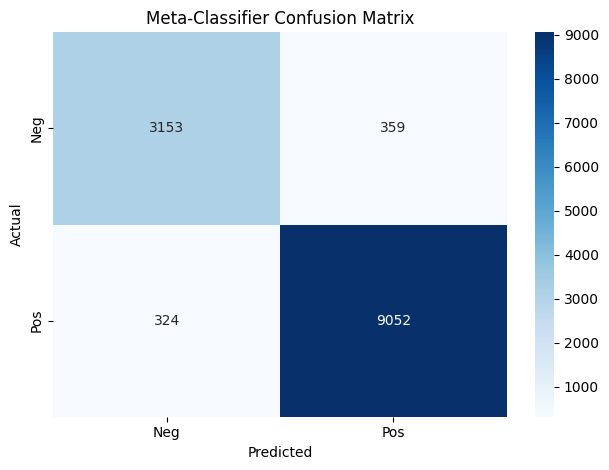

In [25]:
# === Meta-Classifier (Stacked Ensemble) ===
from sklearn.linear_model import LogisticRegression

def get_model_probs(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids, masks, labels = [x.to(device) for x in batch]
            logits = model(input_ids, attention_mask=masks).logits
            probs = torch.softmax(logits, dim=1)
            all_probs.append(probs.cpu())
            all_labels.extend(labels.cpu().numpy())
    return torch.cat(all_probs).numpy(), np.array(all_labels)

bert_val_probs, val_labels = get_model_probs(bert_model, val_loader_b)
roberta_val_probs, _ = get_model_probs(roberta_model, val_loader_r)
X_val = np.hstack((bert_val_probs, roberta_val_probs))

meta_clf = LogisticRegression(max_iter=1000)
meta_clf.fit(X_val, val_labels)

bert_test_probs, test_labels = get_model_probs(bert_model, test_loader_b)
roberta_test_probs, _ = get_model_probs(roberta_model, test_loader_r)
X_test = np.hstack((bert_test_probs, roberta_test_probs))

meta_preds = meta_clf.predict(X_test)

print("\n🔁 Meta-Classifier Ensemble Evaluation")
print(f"Accuracy : {accuracy_score(test_labels, meta_preds):.4f}")
print(classification_report(test_labels, meta_preds, target_names=['Negative', 'Positive']))

# Optional: Confusion Matrix
cm = confusion_matrix(test_labels, meta_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Meta-Classifier Confusion Matrix")
plt.tight_layout()
plt.show()

# 8. Plot metrics

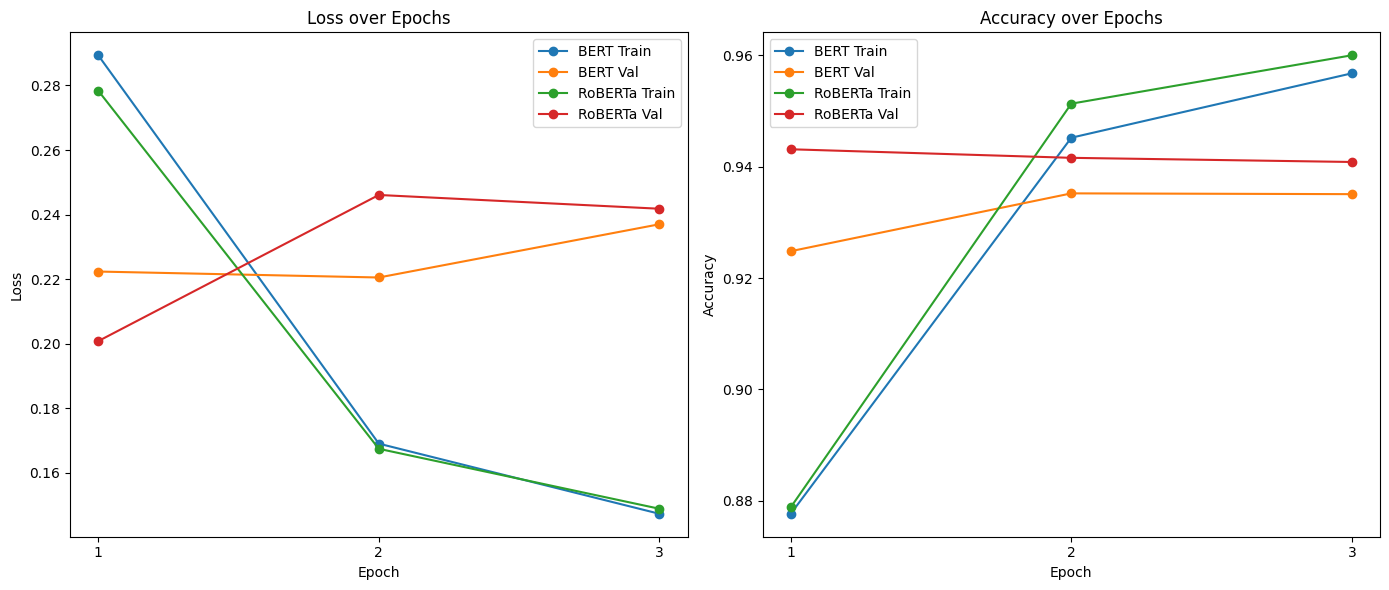

In [29]:
import matplotlib.pyplot as plt

# Assuming these lists are already populated from training:
# b_loss, b_val_loss, r_loss, r_val_loss
# b_acc, b_val_acc, r_acc, r_val_acc

# Auto-generate epoch numbers based on length of results
epochs = list(range(1, len(b_loss) + 1))

plt.figure(figsize=(14,6))

# === LOSS Plot ===
plt.subplot(1,2,1)
plt.plot(epochs, b_loss, label='BERT Train', marker='o')
plt.plot(epochs, b_val_loss, label='BERT Val', marker='o')
plt.plot(epochs, r_loss, label='RoBERTa Train', marker='o')
plt.plot(epochs, r_val_loss, label='RoBERTa Val', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.xticks(epochs)
plt.legend()

# === ACCURACY Plot ===
plt.subplot(1,2,2)
plt.plot(epochs, b_acc, label='BERT Train', marker='o')
plt.plot(epochs, b_val_acc, label='BERT Val', marker='o')
plt.plot(epochs, r_acc, label='RoBERTa Train', marker='o')
plt.plot(epochs, r_val_acc, label='RoBERTa Val', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.xticks(epochs)
plt.legend()

# === Final layout ===
plt.tight_layout()
plt.savefig("training_val_metrics.png", dpi=300)
plt.show()


# Plot Test Accuracy by Class

unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.


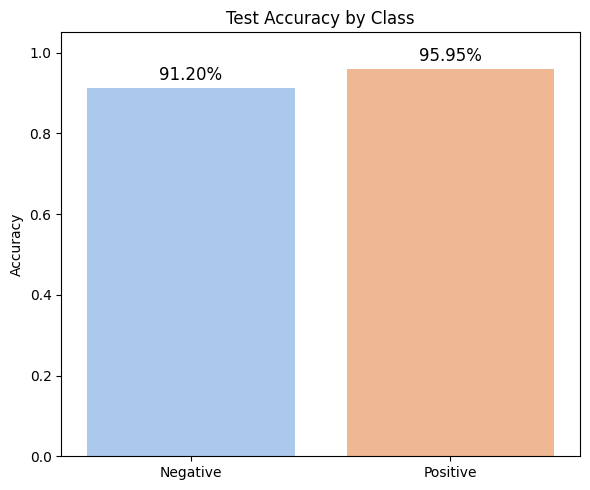

In [27]:
# Calculate per-class test accuracy
classes = ['Negative', 'Positive']
true_labels_arr = np.array(true_labels)
pred_labels_arr = np.array(ensemble_preds)

class_accuracies = []
for label in [0, 1]:
    total = (true_labels_arr == label).sum()
    correct = ((true_labels_arr == label) & (pred_labels_arr == label)).sum()
    acc = correct / total if total > 0 else 0
    class_accuracies.append(acc)

# Plot test accuracy by class
plt.figure(figsize=(6, 5))
sns.barplot(x=classes, y=class_accuracies, palette='pastel')
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("Test Accuracy by Class")
for i, acc in enumerate(class_accuracies):
    plt.text(i, acc + 0.02, f"{acc:.2%}", ha='center', fontsize=12)
plt.tight_layout()
plt.savefig("test_accuracy_by_class.png", dpi=300)
plt.show()

# SHAP

# SHAP EXPLAINABILITY ANALYSIS

In [30]:
# ========== STEP 1: Define SHAP-compatible prediction wrapper ==========
def stacking_predict_text(inputs):
    if isinstance(inputs, np.ndarray):
        texts = [str(x) for x in inputs.tolist()]
    elif isinstance(inputs, list):
        texts = [str(x) for x in inputs]
    else:
        raise ValueError("Unsupported input type for stacking_predict_text")

    # Encode with both BERT and RoBERTa
    bert_enc = bert_tokenizer(texts, padding='max_length', truncation=True,
                              max_length=MAX_LEN, return_tensors='pt')
    roberta_enc = roberta_tokenizer(texts, padding='max_length', truncation=True,
                                    max_length=MAX_LEN, return_tensors='pt')

    bert_ids = bert_enc['input_ids'].to(device)
    bert_mask = bert_enc['attention_mask'].to(device)
    roberta_ids = roberta_enc['input_ids'].to(device)
    roberta_mask = roberta_enc['attention_mask'].to(device)

    # Predict probabilities
    with torch.no_grad():
        b_logits = bert_model(bert_ids, attention_mask=bert_mask).logits
        r_logits = roberta_model(roberta_ids, attention_mask=roberta_mask).logits
        b_probs = torch.softmax(b_logits, dim=1).cpu().numpy()
        r_probs = torch.softmax(r_logits, dim=1).cpu().numpy()

    # Stack BERT and RoBERTa outputs for meta-classifier
    return meta_clf.predict_proba(np.hstack((b_probs, r_probs)))


# ========== STEP 2: Sample input texts for SHAP explanation ==========
sample_texts = df['combined_text'].iloc[:100].tolist()  # Or any 100 text samples


# ========== STEP 3: Create SHAP Text Masker (required for text data) ==========
masker = shap.maskers.Text(tokenizer=bert_tokenizer)


# ========== STEP 4: Create SHAP Explainer for stacking model ==========
explainer = shap.Explainer(stacking_predict_text, masker)


# ========== STEP 5: Compute SHAP values ==========
shap_values = explainer(sample_texts)

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   3%|▎         | 3/100 [00:11<01:00,  1.60it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   4%|▍         | 4/100 [00:19<05:25,  3.39s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

...

PartitionExplainer explainer:  98%|█████████▊| 98/100 [10:20<00:13,  6.69s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  99%|█████████▉| 99/100 [10:26<00:06,  6.71s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 101it [10:37,  6.37s/it]                         


# SHAP VISUALIZATIONS

# Global Explanations

# 1. Summary Bar Plot - Overall Feature Importance for ALL CLASSES

In [34]:
# Define input and labels
texts = df['combined_text'].tolist()
labels = df['sentiment'].tolist()

# Split dataset
X_temp, X_test, y_temp, y_test = train_test_split(
    texts, labels, test_size=0.1, stratify=labels, random_state=SEED
)

X_test_sample = X_test  # same input used in SHAP

# Encode sample texts
encoded_inputs = bert_tokenizer.batch_encode_plus(
    X_test_sample,
    padding='max_length',
    truncation=True,
    max_length=MAX_LEN,
    return_tensors="pt"
)

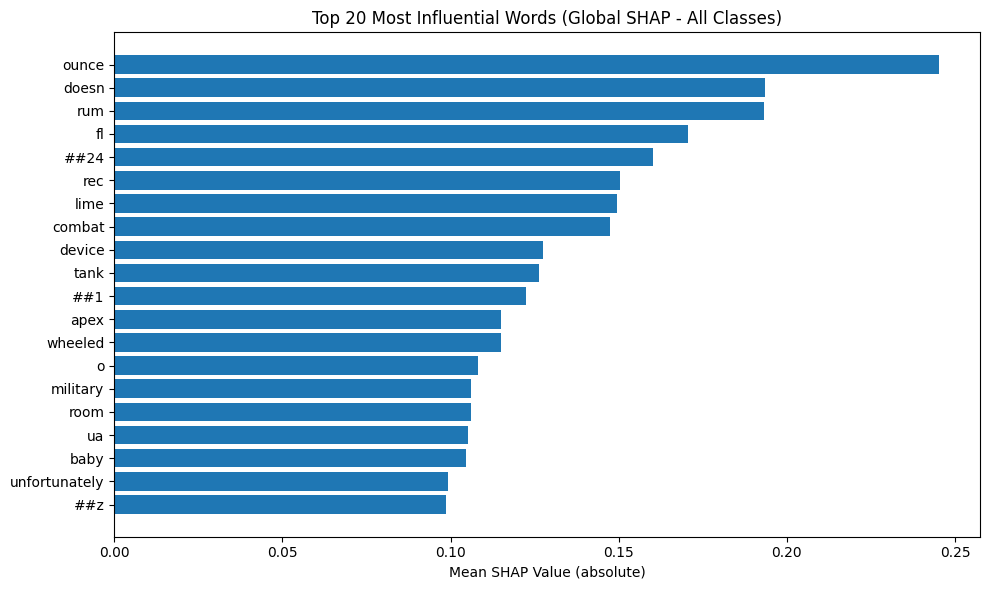

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Token IDs from input
input_ids = encoded_inputs['input_ids'].cpu().numpy()

# Decode tokens
decoded_tokens = [bert_tokenizer.convert_ids_to_tokens(seq) for seq in input_ids]
decoded_tokens = decoded_tokens[:len(shap_values)]  # match length

token_shap_values = {}
for i in range(len(shap_values)):
    shap_len = shap_values[i].values.shape[0]
    for j, token in enumerate(decoded_tokens[i][:shap_len]):
        if token not in token_shap_values:
            token_shap_values[token] = []
        token_shap_values[token].append(np.abs(shap_values[i].values[j]).mean())

mean_shap = {token: np.mean(vals) for token, vals in token_shap_values.items()}
top_tokens = sorted(mean_shap.items(), key=lambda x: x[1], reverse=True)[:20]
tokens, scores = zip(*top_tokens)

plt.figure(figsize=(10, 6))
plt.barh(tokens[::-1], scores[::-1])
plt.xlabel("Mean SHAP Value (absolute)")
plt.title("Top 20 Most Influential Words (Global SHAP - All Classes)")
plt.tight_layout()
plt.show()


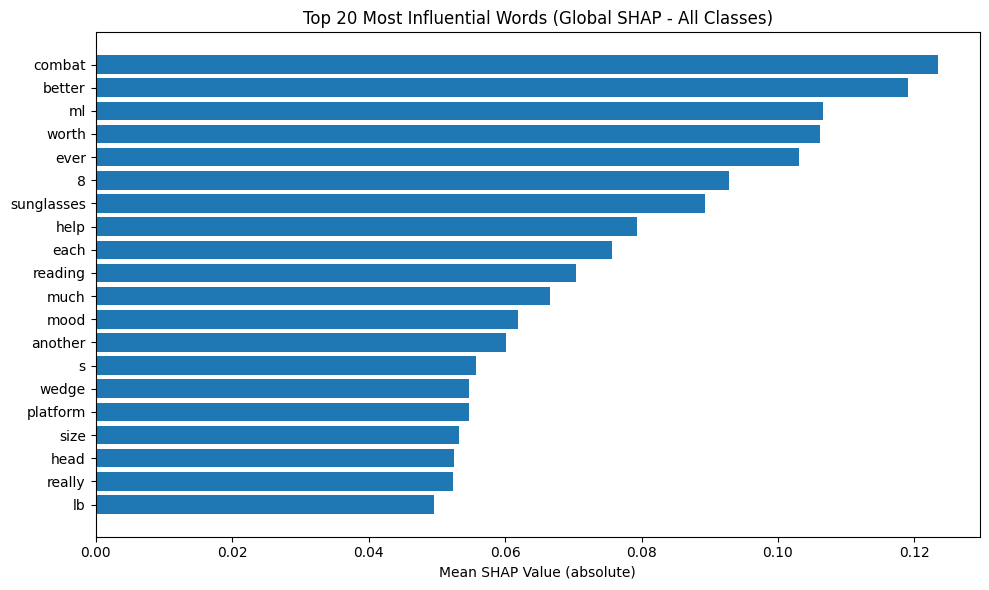

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# STEP 1: Merge subword tokens
def merge_bert_tokens(tokens):
    words = []
    current_word = ""
    for token in tokens:
        if token.startswith("##"):
            current_word += token[2:]
        else:
            if current_word:
                words.append(current_word)
            current_word = token
    if current_word:
        words.append(current_word)
    return words

# STEP 2: Decode only the SHAP'd samples
input_ids = encoded_inputs['input_ids'].cpu().numpy()
decoded_tokens = [bert_tokenizer.convert_ids_to_tokens(seq) for seq in input_ids[:len(shap_values)]]
merged_token_lists = [merge_bert_tokens(tokens) for tokens in decoded_tokens]

# STEP 3: Compute word-level SHAP values
word_importance = {}
for i in range(len(merged_token_lists)):
    for j, word in enumerate(merged_token_lists[i]):
        if j >= shap_values[i].values.shape[0]:  # safety check
            continue
        if word not in word_importance:
            word_importance[word] = []
        word_importance[word].append(np.abs(shap_values[i].values[j]).mean())

# STEP 4: Average SHAP values per word
avg_importance = {word: np.mean(vals) for word, vals in word_importance.items() if len(vals) >= 2}
top_words = sorted(avg_importance.items(), key=lambda x: x[1], reverse=True)[:20]

# STEP 5: Plot
tokens, scores = zip(*top_words)
plt.figure(figsize=(10, 6))
plt.barh(tokens[::-1], scores[::-1])
plt.xlabel("Mean SHAP Value (absolute)")
plt.title("Top 20 Most Influential Words (Global SHAP - All Classes)")
plt.tight_layout()
plt.show()

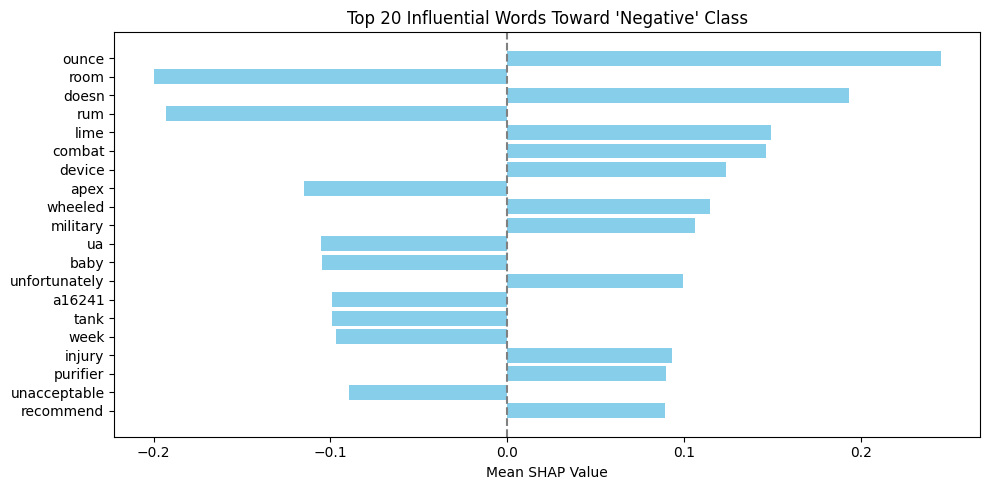

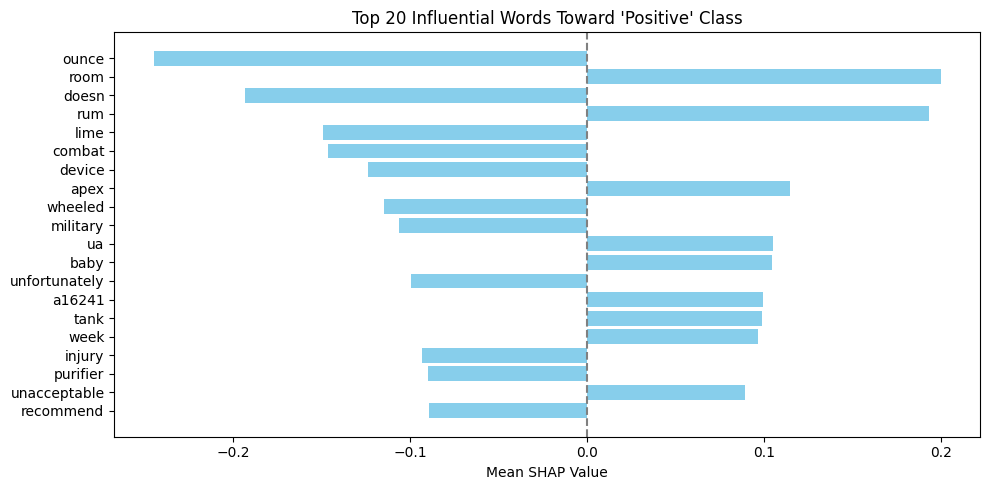

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

# -------------------------------
# Step 1: Merge BERT subword tokens
# -------------------------------
def merge_bert_tokens(tokens, shap_vals):
    words = []
    word_vals = []
    current_word = ""
    current_vals = []

    for token, val in zip(tokens, shap_vals):
        if token in ["[PAD]", "[CLS]", "[SEP]"]:
            continue
        if token.startswith("##"):
            current_word += token[2:]
            current_vals.append(val)
        else:
            if current_word:
                words.append(current_word)
                word_vals.append(np.mean(current_vals))
            current_word = token
            current_vals = [val]
    if current_word and current_vals:
        words.append(current_word)
        word_vals.append(np.mean(current_vals))

    return words, word_vals

# -------------------------------
# Step 2: Build class-wise token impact
# -------------------------------
class_word_impact = [defaultdict(list) for _ in range(2)]  # 2 classes: 0=Negative, 1=Positive

for i in range(len(shap_values)):
    tokens = bert_tokenizer.convert_ids_to_tokens(encoded_inputs['input_ids'][i])
    
    for class_idx in range(2):
        shap_row_vals = shap_values[i].values[:, class_idx]
        words, vals = merge_bert_tokens(tokens, shap_row_vals)
        
        for w, v in zip(words, vals):
            class_word_impact[class_idx][w].append(v)

# -------------------------------
# Step 3: Average SHAP value per token
# -------------------------------
class_word_avg = [
    {token: np.mean(values) for token, values in class_dict.items()}
    for class_dict in class_word_impact
]

# -------------------------------
# Step 4: Plot bar chart for each class
# -------------------------------
class_names = ['Negative', 'Positive']
for c in range(2):
    avg = class_word_avg[c]
    top_words = sorted(avg.items(), key=lambda x: abs(x[1]), reverse=True)[:20]
    words, shap_vals = zip(*top_words)

    plt.figure(figsize=(10, 5))
    plt.barh(words[::-1], shap_vals[::-1], color='skyblue')
    plt.axvline(0, color='gray', linestyle='--')
    plt.title(f"Top 20 Influential Words Toward '{class_names[c]}' Class")
    plt.xlabel("Mean SHAP Value")
    plt.tight_layout()
    plt.show()

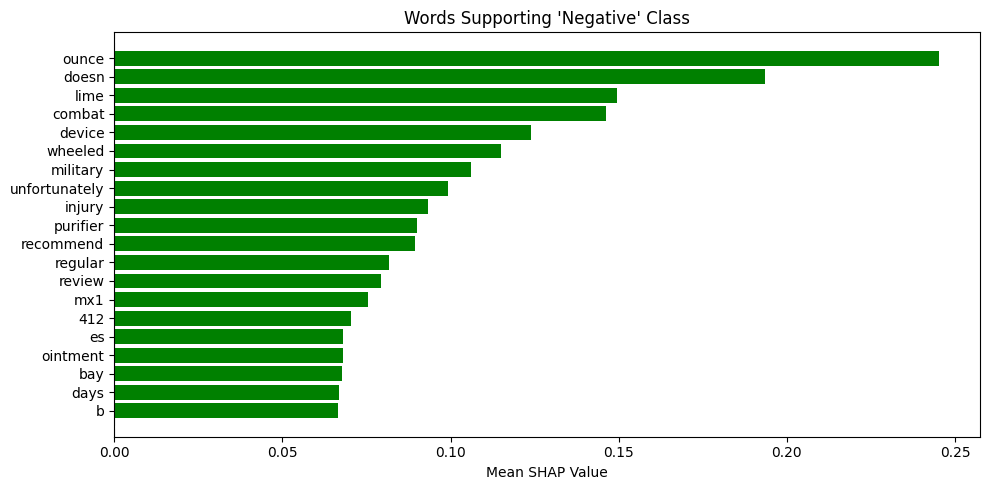

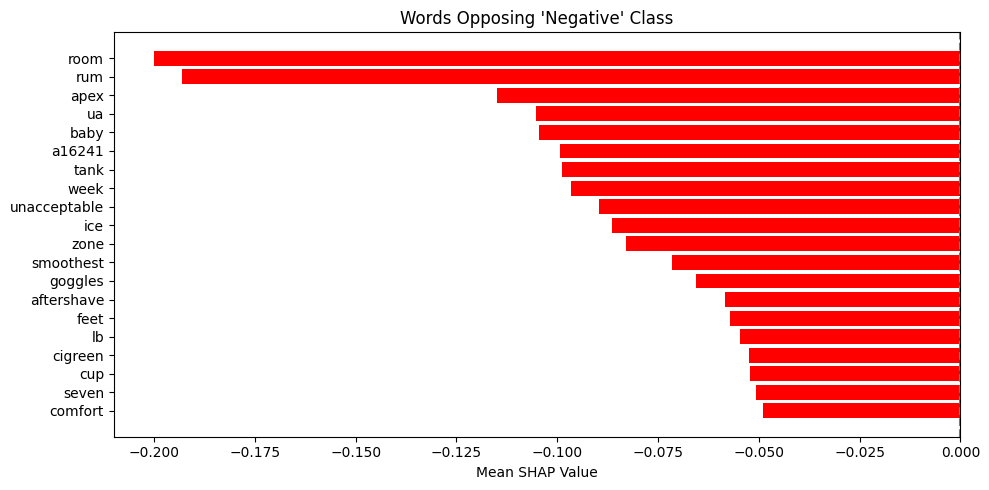

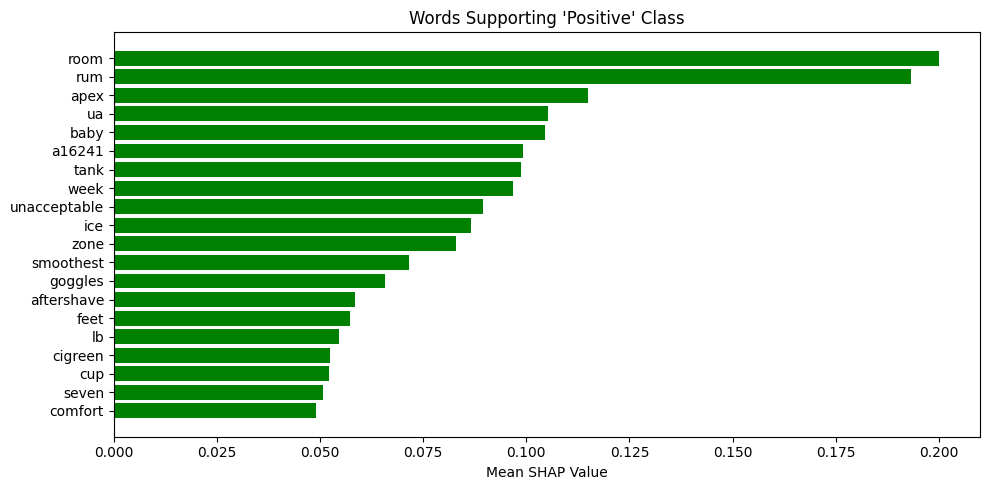

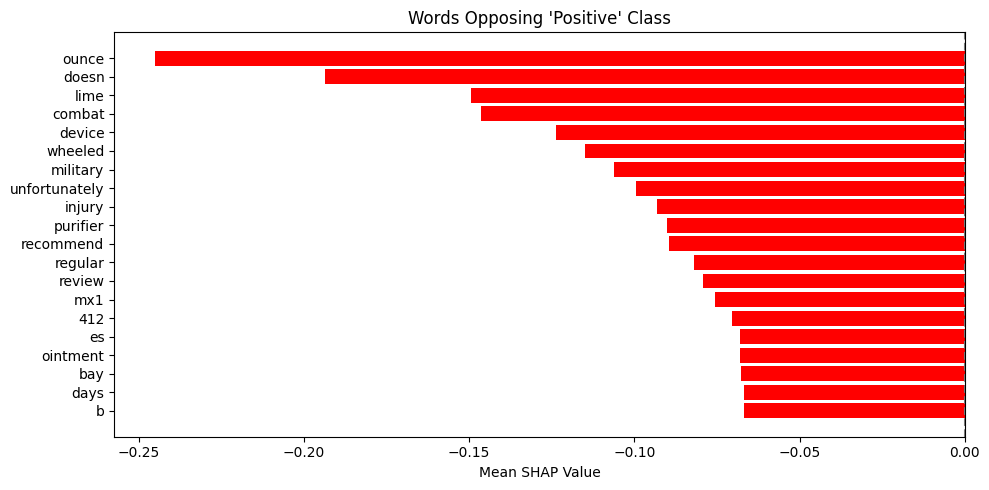

In [41]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

# Class names
class_names = ['Negative', 'Positive']

# Step 1: Decode tokens
input_ids = encoded_inputs['input_ids'].cpu().numpy()
decoded_tokens = [bert_tokenizer.convert_ids_to_tokens(seq) for seq in input_ids]

# Step 2: Define merging function for BERT subwords
def merge_bert_tokens(tokens, shap_vals):
    words = []
    word_vals = []
    current_word = ""
    current_shaps = []

    for token, val in zip(tokens, shap_vals):
        if token in ['[PAD]', '[CLS]', '[SEP]']:
            continue
        if token.startswith("##"):
            current_word += token[2:]
            current_shaps.append(val)
        else:
            if current_word:
                words.append(current_word)
                word_vals.append(np.mean(current_shaps))
            current_word = token
            current_shaps = [val]
    if current_word and current_shaps:
        words.append(current_word)
        word_vals.append(np.mean(current_shaps))

    return words, word_vals

# Step 3: Initialize SHAP storage per class
class_word_impact = [defaultdict(list) for _ in range(2)]  # For each class

# Step 4: Fill SHAP values for each merged word and class
for i in range(len(shap_values.values)):  # Samples
    tokens = decoded_tokens[i]
    for c in range(2):  # Class index: 0=Negative, 1=Positive
        shap_row = shap_values.values[i][:, c]
        merged_words, merged_vals = merge_bert_tokens(tokens, shap_row)
        for word, val in zip(merged_words, merged_vals):
            class_word_impact[c][word].append(val)

# Step 5: Compute mean SHAP value per word per class
class_word_avg = [
    {token: np.mean(contribs) for token, contribs in class_dict.items()}
    for class_dict in class_word_impact
]

# Step 6: Plot support and oppose words per class
for c in range(2):
    word_avg = class_word_avg[c]

    # Supporting words (positive SHAP)
    top_pos = sorted(word_avg.items(), key=lambda x: x[1], reverse=True)[:20]
    words, values = zip(*top_pos)
    plt.figure(figsize=(10, 5))
    plt.barh(words[::-1], values[::-1], color='green')
    plt.title(f"Words Supporting '{class_names[c]}' Class")
    plt.axvline(0, color='gray', linestyle='--')
    plt.xlabel("Mean SHAP Value")
    plt.tight_layout()
    plt.show()

    # Opposing words (negative SHAP)
    top_neg = sorted(word_avg.items(), key=lambda x: x[1])[:20]
    words, values = zip(*top_neg)
    plt.figure(figsize=(10, 5))
    plt.barh(words[::-1], values[::-1], color='red')
    plt.title(f"Words Opposing '{class_names[c]}' Class")
    plt.axvline(0, color='gray', linestyle='--')
    plt.xlabel("Mean SHAP Value")
    plt.tight_layout()
    plt.show()

# 2. Summary Plot (Beeswarm)

 Generating SHAP beeswarm plot with color and labels...


The figure layout has changed to tight


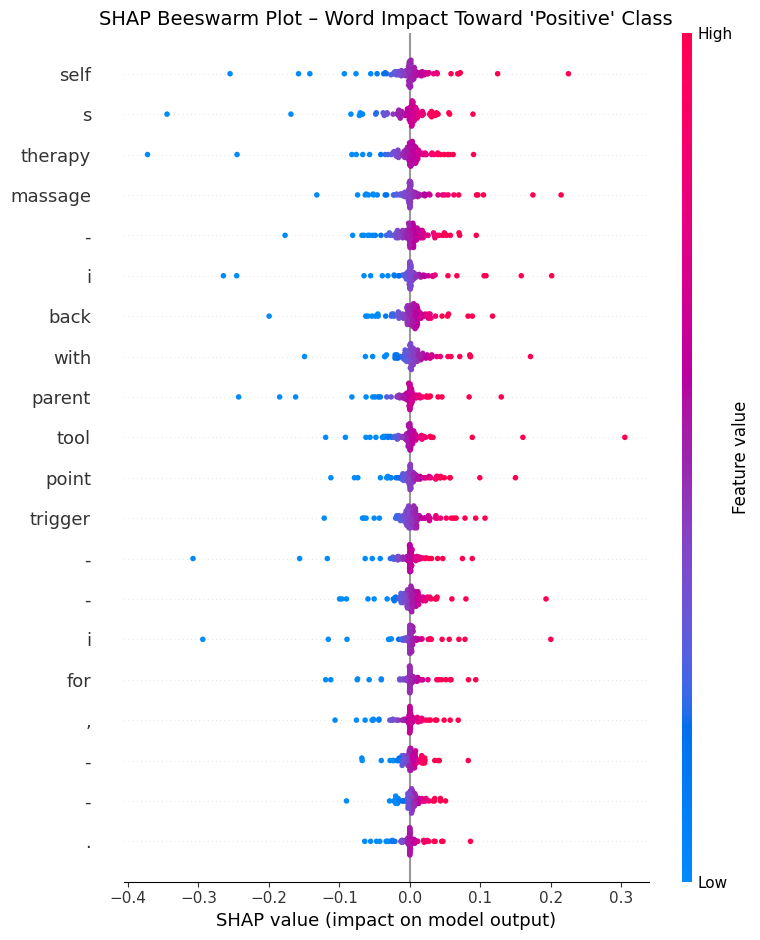

In [53]:
# ===============================
# Step 1: Decode and merge tokens
# ===============================
def merge_bert_tokens(tokens, shap_vals):
    words = []
    word_vals = []
    current_word = ""
    current_vals = []
    
    for token, val in zip(tokens, shap_vals):
        if token in ["[PAD]", "[CLS]", "[SEP]"]:
            continue  # optional: skip special tokens
        if token.startswith("##"):
            current_word += token[2:]
            current_vals.append(val)
        else:
            if current_word:
                words.append(current_word)
                word_vals.append(np.mean(current_vals))
            current_word = token
            current_vals = [val]
    if current_word and current_vals:
        words.append(current_word)
        word_vals.append(np.mean(current_vals))
    
    return words, word_vals

# ===============================
# Step 2: Extract token IDs
# ===============================
input_ids = encoded_inputs['input_ids'].cpu().numpy()
decoded_tokens = [bert_tokenizer.convert_ids_to_tokens(seq) for seq in input_ids]

# ===============================
# Step 3: Merge tokens and SHAP values
# ===============================
num_samples = min(len(decoded_tokens), len(shap_values))  # 🛡 Safe bound

all_words, all_shap_vals = [], []
for i in range(num_samples):
    tokens = decoded_tokens[i]
    shap_row_vals = shap_values[i].values[:, 1]  # Class 1 (or 0)
    words, values = merge_bert_tokens(tokens, shap_row_vals)
    all_words.append(words)
    all_shap_vals.append(values)

# ===============================
# Step 4: Pad all rows to same length
# ===============================
max_len = max(len(seq) for seq in all_words)
padded_words = [seq + ['<pad>'] * (max_len - len(seq)) for seq in all_words]
padded_vals = [vals + [0.0] * (max_len - len(vals)) for vals in all_shap_vals]

# ===============================
# Step 5: Convert to numpy arrays
# ===============================
shap_matrix = np.array(padded_vals)
word_matrix = np.array(padded_words)

# ===============================
# Step 6: Determine feature names
# ===============================
feature_names = []
for col in word_matrix.T:
    counter = Counter(w for w in col if w != '<pad>')
    feature_names.append(counter.most_common(1)[0][0] if counter else '<pad>')

# ===============================
# Step 7: Create SHAP Explanation
# ===============================
expl = shap.Explanation(
    values=shap_matrix,
    base_values=np.mean(shap_values.base_values[:, 1]),
    data=shap_matrix,
    feature_names=feature_names
)

# ===============================
# Step 8: Plot beeswarm
# ===============================
print(" Generating SHAP beeswarm plot with color and labels...")
plt.figure(figsize=(12, 8))
shap.summary_plot(expl, max_display=20, plot_type="dot", show=False)
plt.title("SHAP Beeswarm Plot – Word Impact Toward 'Positive' Class", fontsize=14)
plt.tight_layout()
plt.show()


✅ Generating Clean SHAP Beeswarm Plot (filtered)...


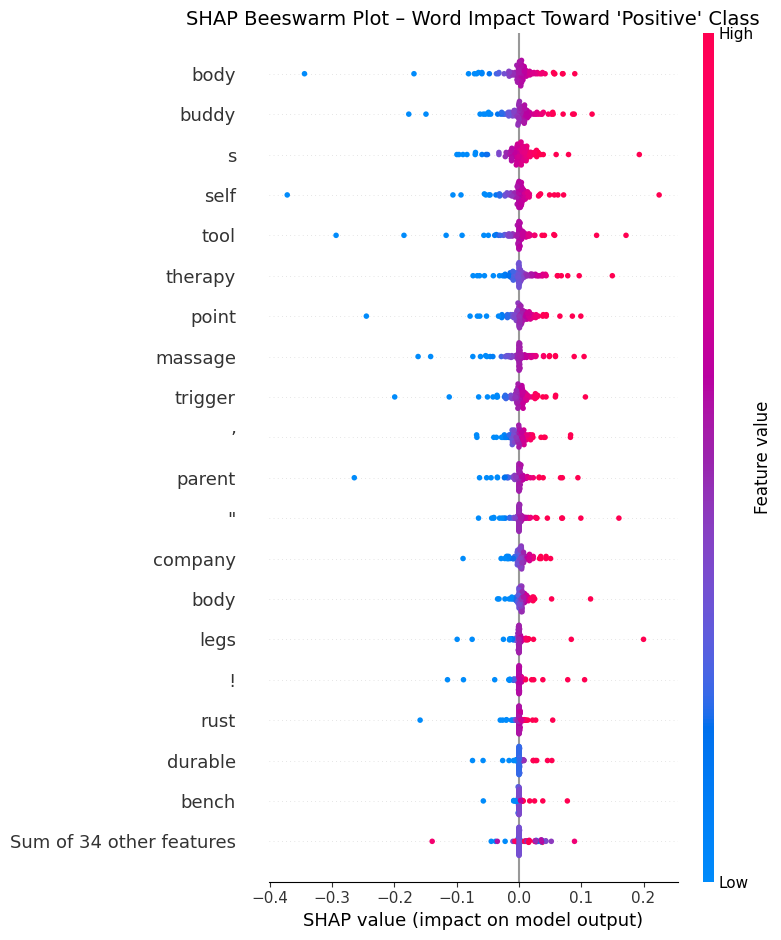

In [55]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# ==================================
# Step 0: Setup stopword and filters
# ==================================
stopwords = set(ENGLISH_STOP_WORDS)
exclude_tokens = {'.', ',', '-', '...', "''", '""'}

# ============================
# Helper: Merge BERT subwords
# ============================
def merge_bert_tokens(tokens, shap_vals):
    merged_tokens = []
    merged_vals = []
    current_token = ""
    current_vals = []

    for token, val in zip(tokens, shap_vals):
        if token in ["[PAD]", "[CLS]", "[SEP]"]:
            continue
        if token.startswith("##"):
            current_token += token[2:]
            current_vals.append(val)
        else:
            if current_token:
                merged_tokens.append(current_token)
                merged_vals.append(np.mean(current_vals))
            current_token = token
            current_vals = [val]

    if current_token and current_vals:
        merged_tokens.append(current_token)
        merged_vals.append(np.mean(current_vals))

    return merged_tokens, merged_vals

# ========================================
# Step 1: Decode token IDs from input_ids
# ========================================
input_ids = encoded_inputs['input_ids'].cpu().numpy()
decoded_tokens_batch = [bert_tokenizer.convert_ids_to_tokens(seq) for seq in input_ids]

# ========================================
# Step 2: Merge tokens and SHAP values
# ========================================
merged_token_list = []
merged_shap_val_list = []

num_samples = min(len(shap_values), len(decoded_tokens_batch))

for i in range(num_samples):
    tokens = decoded_tokens_batch[i]
    shap_vals = shap_values[i].values[:, 1]  # For 'Positive' class
    words, vals = merge_bert_tokens(tokens, shap_vals)

    # ✅ Filter stopwords and punctuation
    filtered = [(w, v) for w, v in zip(words, vals)
                if w.lower() not in stopwords and w not in exclude_tokens]

    if filtered:
        f_words, f_vals = zip(*filtered)
        merged_token_list.append(list(f_words))
        merged_shap_val_list.append(list(f_vals))

# ========================================
# Step 3: Pad SHAP arrays
# ========================================
max_len = max(len(seq) for seq in merged_token_list)
padded_shap = np.array([vals + [0.0] * (max_len - len(vals)) for vals in merged_shap_val_list])
padded_tokens = [words + [''] * (max_len - len(words)) for words in merged_token_list]

# ========================================
# Step 4: Determine most common token per column
# ========================================
feature_names = []
for col in zip(*padded_tokens):  # Transpose
    counter = Counter(w for w in col if w and w != '<pad>')
    most_common = counter.most_common(1)
    feature_names.append(most_common[0][0] if most_common else "<pad>")

# ========================================
# Step 5: Create SHAP Explanation
# ========================================
expl = shap.Explanation(
    values=padded_shap,
    base_values=np.mean(shap_values.base_values[:, 1]),
    data=padded_shap,
    feature_names=feature_names
)

# ========================================
# Step 6: Plot Beeswarm with title
# ========================================
plt.close('all')
print("✅ Generating Clean SHAP Beeswarm Plot (filtered)...")
shap.plots.beeswarm(expl, max_display=20, show=False)  # Disable auto-show
plt.title("SHAP Beeswarm Plot – Word Impact Toward 'Positive' Class", fontsize=14)
plt.tight_layout()
plt.show()


✅ Generating Clean SHAP Beeswarm Plot (filtered)...


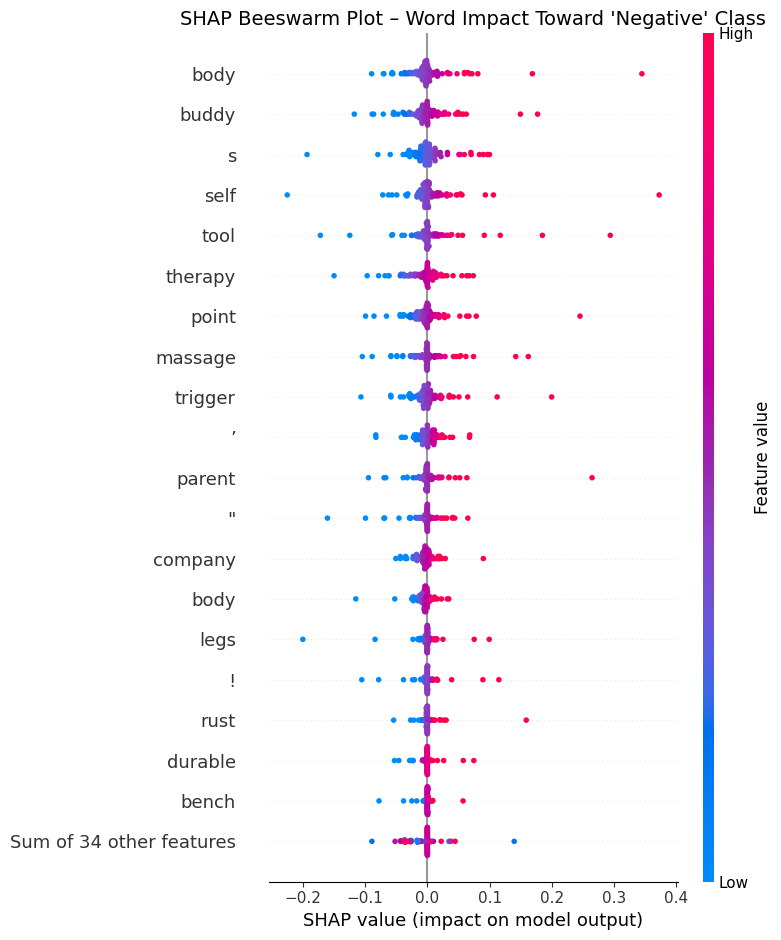

In [56]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# ==================================
# Step 0: Setup stopword and filters
# ==================================
stopwords = set(ENGLISH_STOP_WORDS)
exclude_tokens = {'.', ',', '-', '...', "''", '""'}

# ============================
# Helper: Merge BERT subwords
# ============================
def merge_bert_tokens(tokens, shap_vals):
    merged_tokens = []
    merged_vals = []
    current_token = ""
    current_vals = []

    for token, val in zip(tokens, shap_vals):
        if token in ["[PAD]", "[CLS]", "[SEP]"]:
            continue
        if token.startswith("##"):
            current_token += token[2:]
            current_vals.append(val)
        else:
            if current_token:
                merged_tokens.append(current_token)
                merged_vals.append(np.mean(current_vals))
            current_token = token
            current_vals = [val]

    if current_token and current_vals:
        merged_tokens.append(current_token)
        merged_vals.append(np.mean(current_vals))

    return merged_tokens, merged_vals

# ========================================
# Step 1: Decode token IDs from input_ids
# ========================================
input_ids = encoded_inputs['input_ids'].cpu().numpy()
decoded_tokens_batch = [bert_tokenizer.convert_ids_to_tokens(seq) for seq in input_ids]

# ========================================
# Step 2: Merge tokens and SHAP values
# ========================================
merged_token_list = []
merged_shap_val_list = []

num_samples = min(len(shap_values), len(decoded_tokens_batch))

for i in range(num_samples):
    tokens = decoded_tokens_batch[i]
    shap_vals = shap_values[i].values[:, 0]  # For 'Positive' class
    words, vals = merge_bert_tokens(tokens, shap_vals)

    # ✅ Filter stopwords and punctuation
    filtered = [(w, v) for w, v in zip(words, vals)
                if w.lower() not in stopwords and w not in exclude_tokens]

    if filtered:
        f_words, f_vals = zip(*filtered)
        merged_token_list.append(list(f_words))
        merged_shap_val_list.append(list(f_vals))

# ========================================
# Step 3: Pad SHAP arrays
# ========================================
max_len = max(len(seq) for seq in merged_token_list)
padded_shap = np.array([vals + [0.0] * (max_len - len(vals)) for vals in merged_shap_val_list])
padded_tokens = [words + [''] * (max_len - len(words)) for words in merged_token_list]

# ========================================
# Step 4: Determine most common token per column
# ========================================
feature_names = []
for col in zip(*padded_tokens):  # Transpose
    counter = Counter(w for w in col if w and w != '<pad>')
    most_common = counter.most_common(1)
    feature_names.append(most_common[0][0] if most_common else "<pad>")

# ========================================
# Step 5: Create SHAP Explanation
# ========================================
expl = shap.Explanation(
    values=padded_shap,
    base_values=np.mean(shap_values.base_values[:, 1]),
    data=padded_shap,
    feature_names=feature_names
)

# ========================================
# Step 6: Plot Beeswarm with title
# ========================================
plt.close('all')
print("✅ Generating Clean SHAP Beeswarm Plot (filtered)...")
shap.plots.beeswarm(expl, max_display=20, show=False)  # Disable auto-show
plt.title("SHAP Beeswarm Plot – Word Impact Toward 'Negative' Class", fontsize=14)
plt.tight_layout()
plt.show()


In [49]:
print("SHAP shape:", shap_values[0].values.shape)  # should be (tokens, 2)
print("Positive sample SHAP avg:", np.mean([s.values[:, 1].mean() for s in shap_values]))
print("Negative sample SHAP avg:", np.mean([s.values[:, 0].mean() for s in shap_values]))


SHAP shape: (54, 2)
Positive sample SHAP avg: 0.00044346541873829706
Negative sample SHAP avg: -0.00044346541873829706


# 3. SHAP Heatmap by Class

invalid value encountered in less


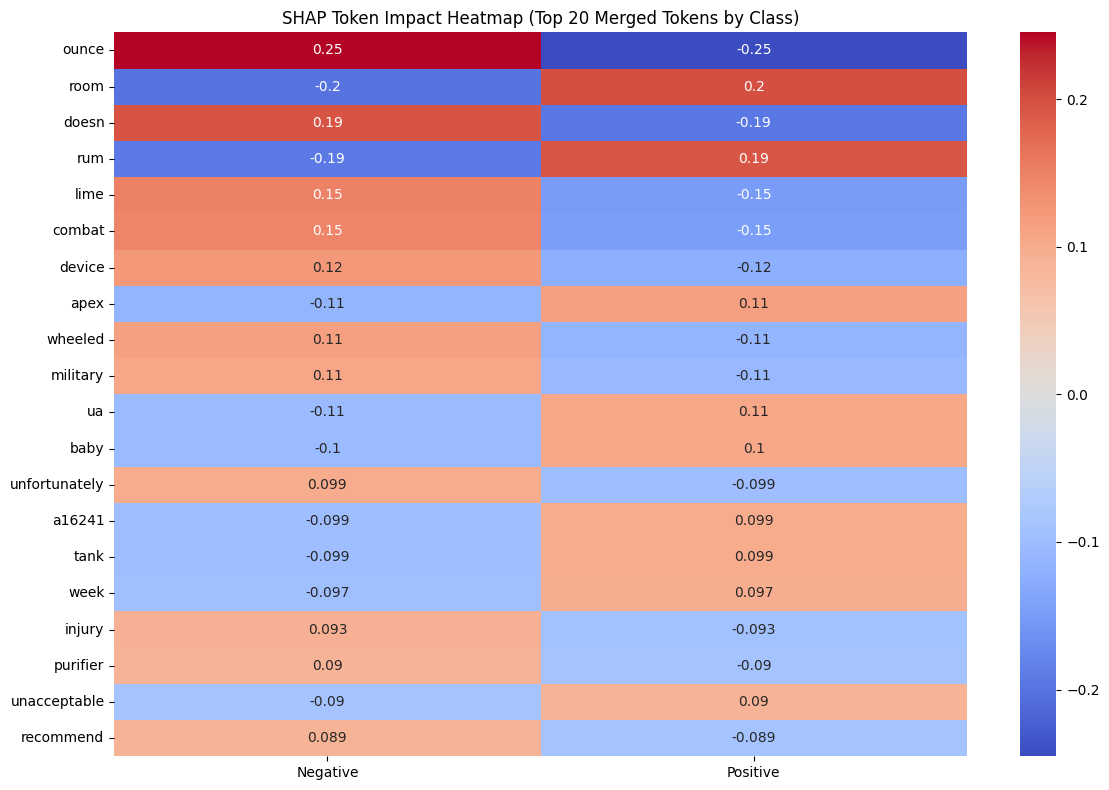

In [59]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

# Step 1: Decode and merge subword tokens
def merge_bert_tokens(tokens, shap_vals):
    merged_tokens = []
    merged_vals = []
    current_token = ""
    current_val = []

    for token, val in zip(tokens, shap_vals):
        if token in ["[PAD]", "[CLS]", "[SEP]"]:
            continue
        if token.startswith("##"):
            current_token += token[2:]
            current_val.append(val)
        else:
            if current_token:
                merged_tokens.append(current_token)
                merged_vals.append(np.mean(current_val, axis=0))
            current_token = token
            current_val = [val]
    if current_token:
        merged_tokens.append(current_token)
        merged_vals.append(np.mean(current_val, axis=0))
    
    return merged_tokens, merged_vals

# Step 2: Decode tokens
token_ids = encoded_inputs['input_ids'].cpu().numpy()
decoded_tokens_batch = [bert_tokenizer.convert_ids_to_tokens(seq) for seq in token_ids]

# Step 3: Collect and merge SHAP values
token_shap_by_class = defaultdict(lambda: [0.0, 0.0])
token_counts = defaultdict(int)

for i in range(len(shap_values)):
    tokens = decoded_tokens_batch[i]
    shap_vals = shap_values[i].values  # shape (seq_len, 2)
    merged_tokens, merged_vals = merge_bert_tokens(tokens, shap_vals.tolist())
    
    for tok, val in zip(merged_tokens, merged_vals):
        token_shap_by_class[tok][0] += val[0]
        token_shap_by_class[tok][1] += val[1]
        token_counts[tok] += 1

# Step 4: Normalize SHAP values by frequency
for token in token_shap_by_class:
    count = token_counts[token]
    token_shap_by_class[token] = [v / count for v in token_shap_by_class[token]]

# Step 5: Build DataFrame
df_tokens = pd.DataFrame(token_shap_by_class).T
df_tokens.columns = ['Negative', 'Positive']

# Step 6: Sort by total absolute impact and display top 20
df_tokens['abs_max'] = df_tokens.abs().max(axis=1)
df_top = df_tokens.sort_values('abs_max', ascending=False).drop(columns='abs_max').head(20)

# Step 7: Plot heatmap for both classes
plt.figure(figsize=(12, 8))
sns.heatmap(df_top, annot=True, cmap="coolwarm", center=0)
plt.title("SHAP Token Impact Heatmap (Top 20 Merged Tokens by Class)")
plt.tight_layout()
plt.show()


# Local Explanations

# 3. Force Plots


In [58]:
from transformers import BertTokenizer
import shap
import numpy as np

print("\n🔄 Generating SHAP Force Plots (Merged Tokens) for Sample Predictions")

# Loop over desired samples
for i in range(3):  # You can change this range
    sample = shap_values[i]

    for class_idx, class_label in enumerate(["Negative", "Positive"]):
        print(f"\n🔍 Force plot for class: {class_label}")

        # ✅ Step 1: Tokenize raw text directly (matches SHAP input)
        tokens = bert_tokenizer.tokenize(sample_texts[i])  # NOT from input_ids

        # Step 2: Get SHAP values for this class
        token_shap_vals = sample.values[:, class_idx]

        # ✅ Step 3: Merge subword tokens
        merged_tokens = []
        merged_values = []

        current_token = ""
        current_vals = []

        for token, val in zip(tokens, token_shap_vals):
            if token.startswith("##"):
                current_token += token[2:]
                current_vals.append(val)
            else:
                if current_token:
                    merged_tokens.append(current_token)
                    merged_values.append(np.mean(current_vals))
                current_token = token
                current_vals = [val]

        # Add the last token group
        if current_token:
            merged_tokens.append(current_token)
            merged_values.append(np.mean(current_vals))

        # ✅ Step 4: Create SHAP Explanation
        expl = shap.Explanation(
            values=np.array(merged_values),
            base_values=sample.base_values[class_idx],
            data=merged_tokens
        )

        # ✅ Step 5: Show force plot
        shap.plots.text(expl)


🔄 Generating SHAP Force Plots (Merged Tokens) for Sample Predictions

🔍 Force plot for class: Negative



🔍 Force plot for class: Positive



🔍 Force plot for class: Negative



🔍 Force plot for class: Positive



🔍 Force plot for class: Negative



🔍 Force plot for class: Positive


In [60]:
# Print the first 5 raw text samples used in SHAP
print("🔍 First 5 SHAP Sample Texts:")
for i, text in enumerate(sample_texts[:10]):
    print(f"\nSample {i+1}:")
    print(text)

🔍 First 5 SHAP Sample Texts:

Sample 1:
Elite Sportz Exercise Sliders are Double Sided and Work Smoothly on Any Surface. Wide Variety of Low Impact Exercise’s You Can Do. Full Body Workout, Compact for Travel or Home Ab Workout Good quality. Shipped Exactly as described. Good quality. Shipped fast

Sample 2:
Ezy Dose Weekly Five Stars It is great

Sample 3:
Pulse Oximeter, Blood Oxygen Monitor It's really nice it works great It's really nice it works great. You have the option for it to beep or not . Easy to use. Im very pleased

Sample 4:
SE Tools Tool Kit Watch Watch Repair Kit (20 Piece) Two Stars The kit works fine... simple cheap plastic tho

Sample 5:
doTERRA HD Clear Facial Kit - Facial Lotion, Foaming Face Wash, and HD Clear Blend Four Stars It works better than anything else ive tried

Sample 6:
Viva Naturals #1 Best Selling Certified Organic Cacao Powder from Superior Criollo Beans, 1 LB Bag not bad at all I added to my oatmeal and protein shakes, not bad at all..

Sample 7:


# 4. Waterfall Plots


 Generating SHAP Waterfall Plots (Filtered and Cleaned Tokens)


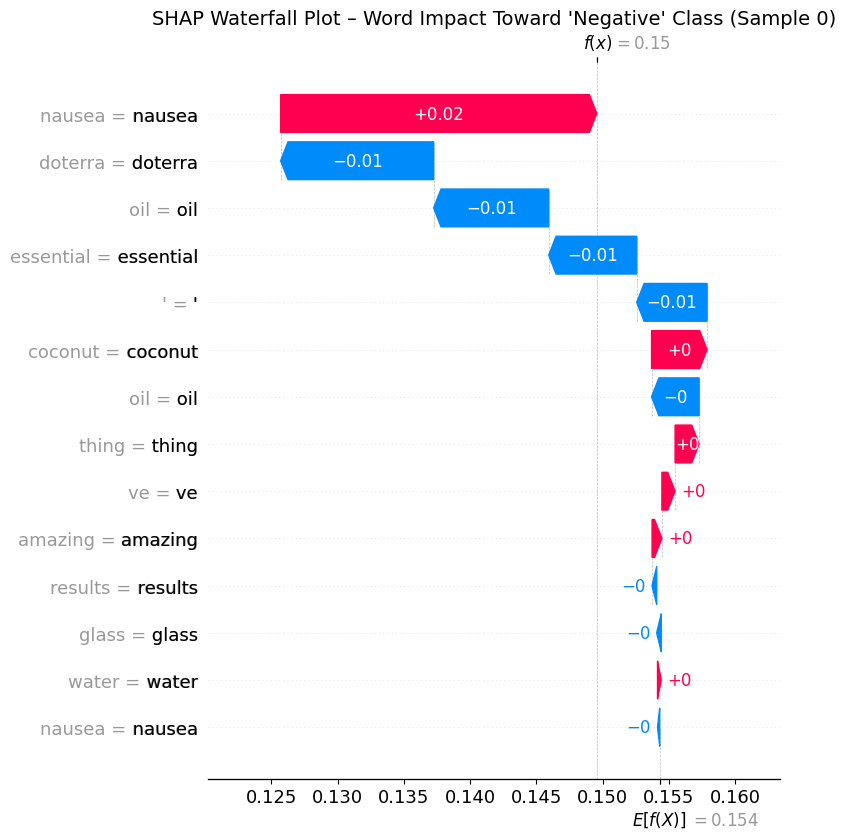

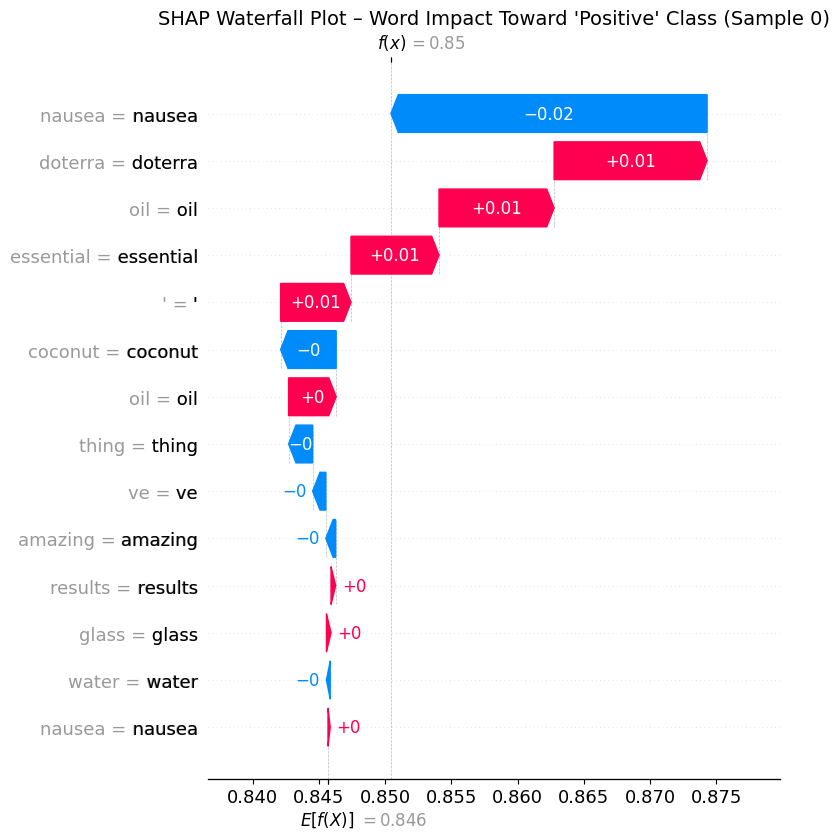

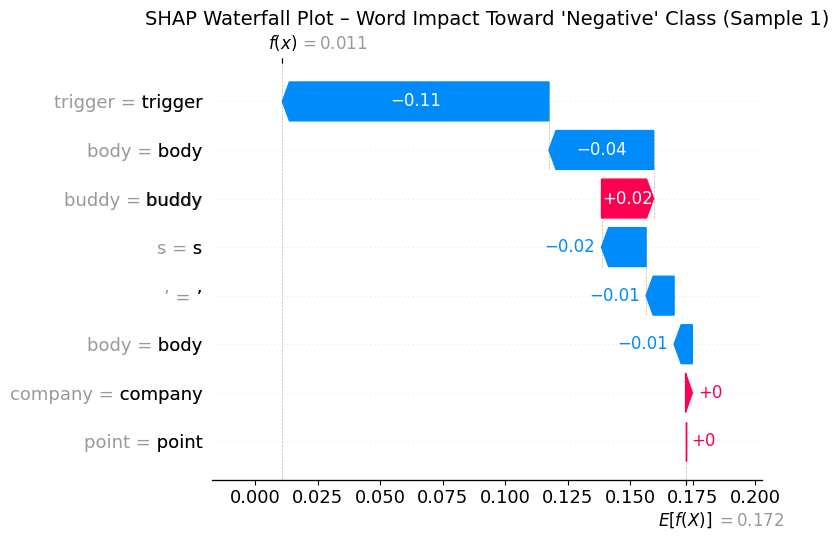

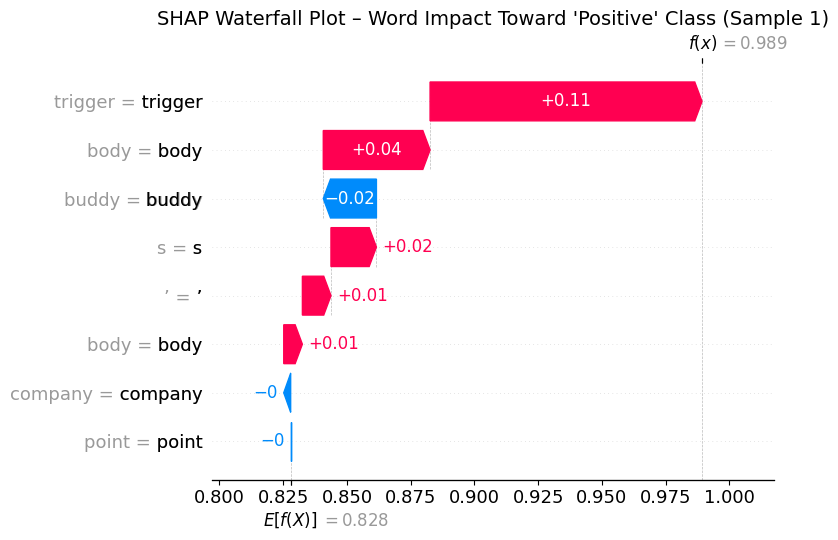

In [70]:
import shap
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# ====================================
# Predefined Filters
# ====================================
stopwords = set(ENGLISH_STOP_WORDS)
exclude_tokens = {'.', ',', '-', '...', "''", '""', '[PAD]', '[CLS]', '[SEP]'}
min_freq = 2  # Adjust as needed

# ====================================
# Helper: Merge and Clean Tokens
# ====================================
def merge_clean_tokens(tokens, shap_vals):
    merged_tokens, merged_vals = [], []
    current_word, current_vals = "", []

    for token, val in zip(tokens, shap_vals):
        if token in exclude_tokens:
            continue
        if token.startswith("##"):
            current_word += token[2:]
            current_vals.append(val)
        else:
            if current_word:
                merged_tokens.append(current_word)
                merged_vals.append(np.mean(current_vals))
            current_word = token
            current_vals = [val]

    if current_word and current_vals:
        merged_tokens.append(current_word)
        merged_vals.append(np.mean(current_vals))

    return merged_tokens, merged_vals

# ====================================
# Count frequency across all samples
# ====================================
token_ids = encoded_inputs['input_ids'].cpu().numpy()
decoded_tokens_batch = [bert_tokenizer.convert_ids_to_tokens(seq) for seq in token_ids]

token_counter = Counter()

num_samples = min(len(shap_values), len(decoded_tokens_batch))

for i in range(num_samples):
    tokens = decoded_tokens_batch[i]
    shap_vals = shap_values[i].values[:, 0]  # class 0 or 1, just to extract shape
    merged_tokens, _ = merge_clean_tokens(tokens, shap_vals)
    token_counter.update([t for t in merged_tokens if t.lower() not in stopwords and t not in exclude_tokens])

# ====================================
# Generate per-class SHAP waterfall plots
# ====================================
print("\n Generating SHAP Waterfall Plots (Filtered and Cleaned Tokens)")

sample_indices = [0, 1]  # Modify as needed

for i in sample_indices:
    shap_sample = shap_values[i]
    tokens = decoded_tokens_batch[i]

    for class_idx, class_label in zip([0, 1], ["Negative", "Positive"]):
        try:
            raw_vals = shap_sample.values[:, class_idx]
            merged_tokens, merged_vals = merge_clean_tokens(tokens, raw_vals)

            # Apply stopword and freq filters
            filtered = [(t, v) for t, v in zip(merged_tokens, merged_vals)
                        if t.lower() not in stopwords and t not in exclude_tokens and token_counter[t] >= min_freq]

            if not filtered:
                print(f" No valid tokens for Sample {i} – Class '{class_label}' after filtering.")
                continue

            filt_tokens, filt_vals = zip(*filtered)

            explanation = shap.Explanation(
                values=np.array(filt_vals),
                base_values=shap_sample.base_values[class_idx],
                data=filt_tokens,
                feature_names=filt_tokens
            )

            shap.plots.waterfall(explanation, max_display=20, show=False)
            plt.title(f"SHAP Waterfall Plot – Word Impact Toward '{class_label}' Class (Sample {i})", fontsize=14)
            plt.tight_layout()
            plt.show()

        except IndexError as e:
            print(f" Skipping Sample {i} for class '{class_label}':", str(e))
